<a href="https://colab.research.google.com/github/Nusrahkhan/HealthCare-Assignment/blob/main/healthcare_ds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## UNDERSTANDING DATASET

In [ ]:
import pandas as pd

df = pd.read_csv('healthcare_costs.csv')

In [ ]:
df.head()

,PatientID,Age,BMI,SmokingStatus,ChronicCondition,AnnualCost
0,1001,58,37.0,Non-Smoker,Yes,6725.12
1,1002,71,33.1,Smoker,Yes,17359.16
2,1003,48,28.2,Smoker,Yes,7259.34
3,1004,34,18.8,Non-Smoker,Yes,12287.21
4,1005,62,38.8,Non-Smoker,Yes,8334.85


In [ ]:
df.ChronicCondition.value_counts()

,count
ChronicCondition,
Yes,27
No,23


In [ ]:
df.PatientID.duplicated().sum()

np.int64(0)

###USING VISUALISATIONS TO UNDERSTAND CORRELATION

[]

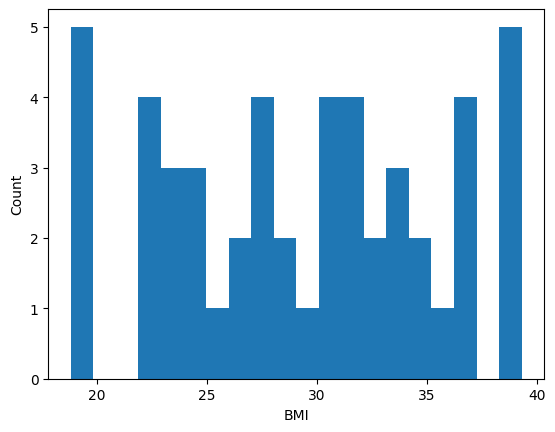

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["BMI"], bins = 20)
plt.xlabel("BMI")
plt.ylabel("Count")
plt.plot()

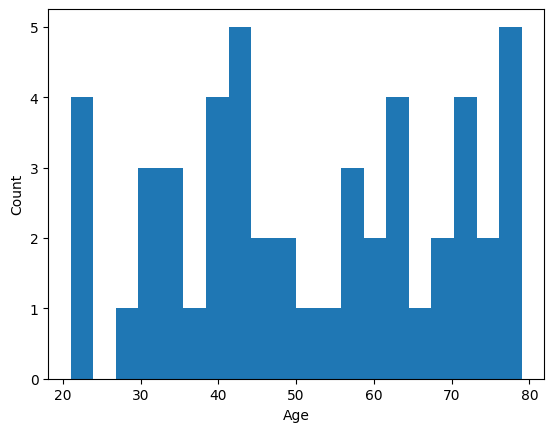

In [ ]:
plt.hist(df["Age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

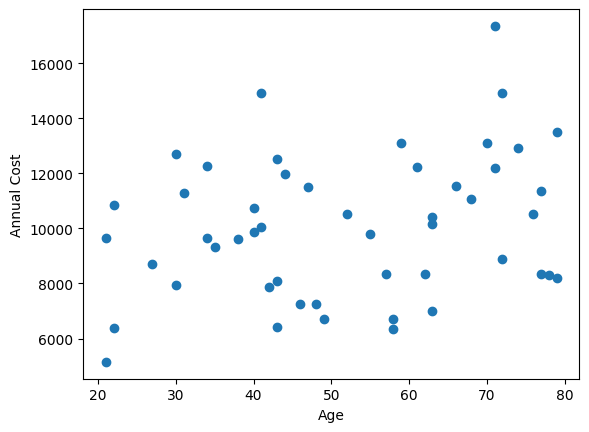

In [ ]:
plt.scatter(df["Age"], df["AnnualCost"])
plt.xlabel("Age")
plt.ylabel("Annual Cost")
plt.show()

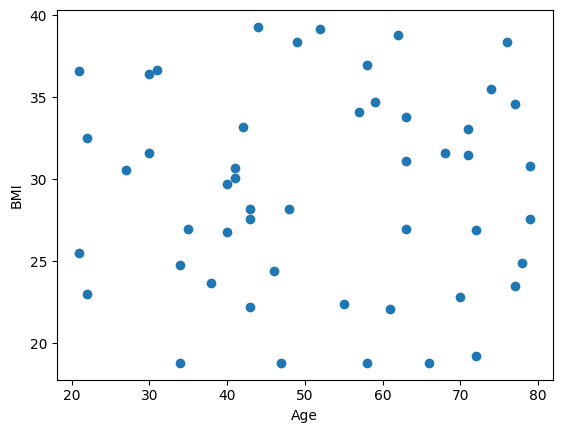

In [ ]:
plt.scatter(df["Age"], df["BMI"])
plt.xlabel("Age")
plt.ylabel("BMI")
plt.show()

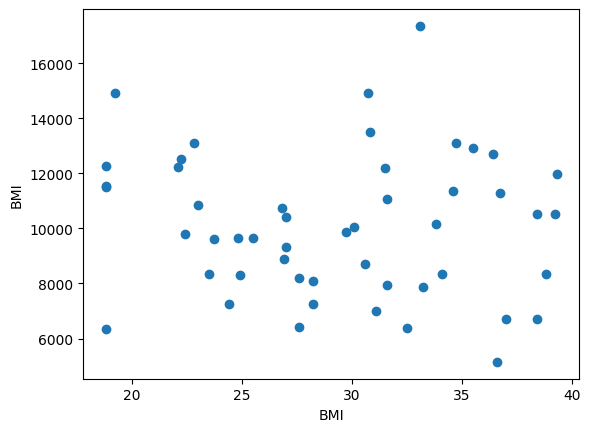

In [ ]:
plt.scatter(df["BMI"], df["AnnualCost"])
plt.xlabel("BMI")
plt.ylabel("BMI")
plt.show()

In [ ]:
print(df[["Age", "BMI", "AnnualCost"]].corr())

                 Age       BMI  AnnualCost
Age         1.000000 -0.006628    0.262913
BMI        -0.006628  1.000000   -0.092863
AnnualCost  0.262913 -0.092863    1.000000


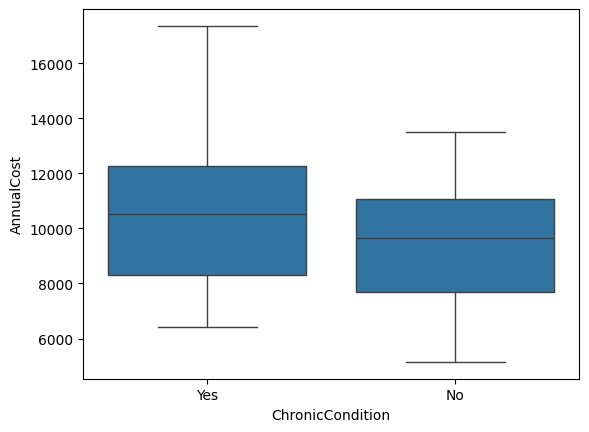

In [ ]:
import seaborn as sns

sns.boxplot(data=df, x="ChronicCondition", y="AnnualCost")
plt.show()

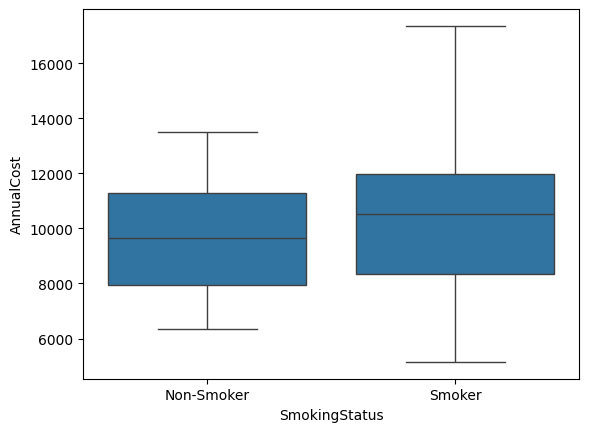

In [ ]:
import seaborn as sns

sns.boxplot(data=df, x="SmokingStatus", y="AnnualCost")
plt.show()

In [ ]:
df.groupby("ChronicCondition")["AnnualCost"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
ChronicCondition,,,,,,
No,23,9458.156522,9656.77,2276.995399,5150.22,13503.30
Yes,27,10612.283704,10542.34,2734.973391,6433.80,17359.16


In [ ]:
df.groupby("SmokingStatus")["AnnualCost"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
SmokingStatus,,,,,,
Non-Smoker,21,9614.009524,9641.34,2210.504615,6353.71,13503.30
Smoker,29,10419.829655,10542.34,2799.576199,5150.22,17359.16


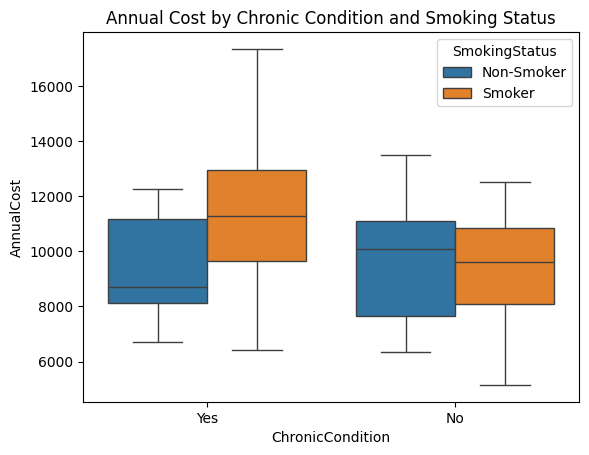

In [ ]:
sns.boxplot(
    data=df,
    x="ChronicCondition",
    y="AnnualCost",
    hue="SmokingStatus"
)

plt.title("Annual Cost by Chronic Condition and Smoking Status")
plt.show()

In [ ]:
df.groupby(
    ["ChronicCondition", "SmokingStatus"]
)["AnnualCost"].agg(
    ["count", "mean", "median", "std"]
)

count          mean     median          std
ChronicCondition SmokingStatus                                             
No               Non-Smoker        10   9750.097000  10105.620  2547.237567
                 Smoker            13   9233.586923   9633.820  2124.458795
Yes              Non-Smoker        11   9490.293636   8715.530  1974.266451
                 Smoker            16  11383.651875  11296.215  2968.020272

###CHECKING OUTLIERS

> Add blockquote



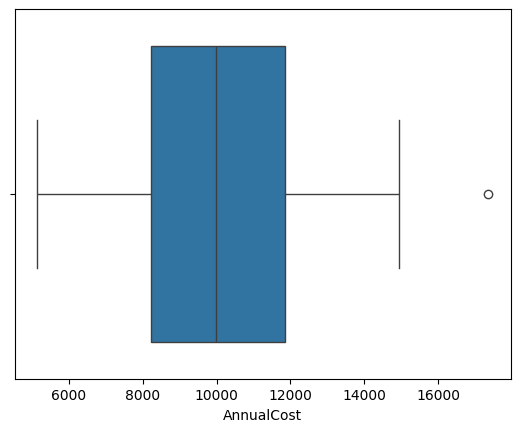

In [ ]:
sns.boxplot(x=df["AnnualCost"])
plt.show()

[]

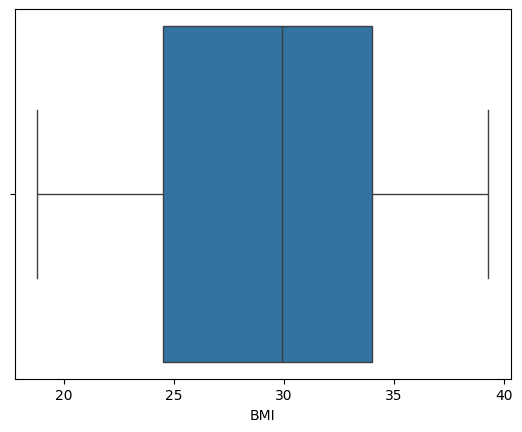

In [ ]:
sns.boxplot(x = df["BMI"])
plt.plot()

###CHECKING DISTRIBUTION OF TARGET VARIABLE

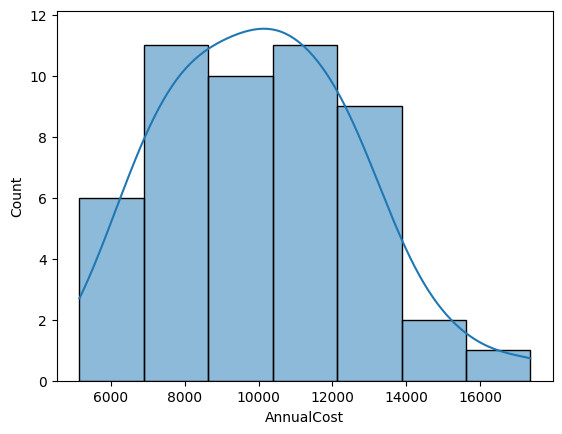

In [ ]:
sns.histplot(df["AnnualCost"], kde=True)
plt.show()

###PREPROCESSING DATA

In [ ]:
df_encoded = pd.get_dummies(df, columns = ['ChronicCondition', 'SmokingStatus'], dtype = 'int')

##REGRESSION

In [ ]:
x = df_encoded.drop(columns=["AnnualCost", "PatientID"])
y = df_encoded["AnnualCost"]

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 40)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

LinearRegression()

In [ ]:
predictions = lr.predict(x_test)

###EVALUATING THE MODEL

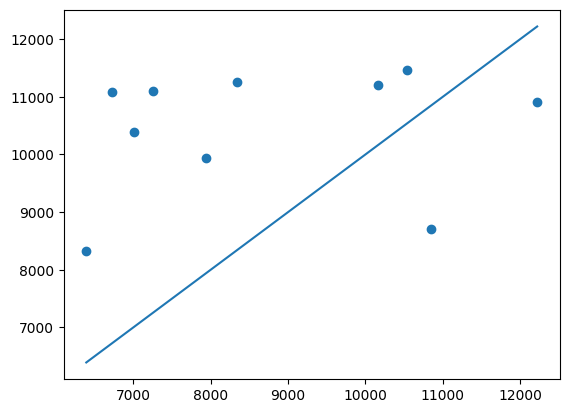

In [ ]:
plt.scatter(x = y_test, y = predictions)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)

MAE: 2383.3241333959363


In [ ]:
from sklearn.metrics import mean_squared_error

rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

print("RMSE:", rmse)

RMSE: 2639.018355685393


In [ ]:
from sklearn.metrics import r2_score

r2_lr = r2_score(y_test, predictions)
print(r2_lr)

-0.863210007107938


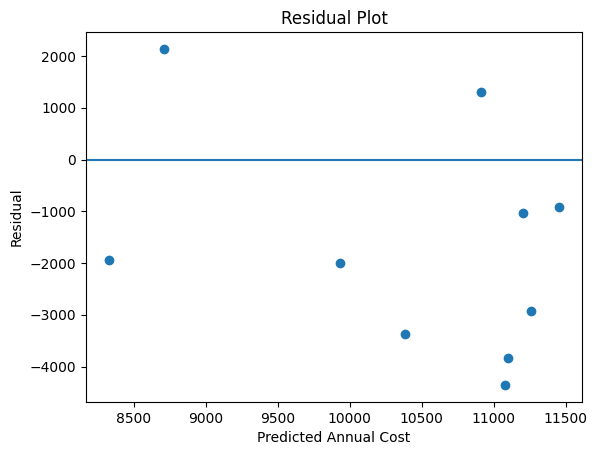

In [ ]:
residuals = y_test - predictions

plt.scatter(predictions, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Annual Cost")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

###RANDOM FOREST REGRESSOR

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score

model_2 = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model_2.fit(x_train, y_train)

predictions_2 = model_2.predict(x_test)

###EVALUATING THE MODEL

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions_2)
print("MAE:", mae)

MAE: 2375.7263966666665


In [ ]:
from sklearn.metrics import mean_squared_error

rmse = mean_squared_error(
    y_test,
    predictions_2
) ** 0.5

print("RMSE:", rmse)

RMSE: 2737.346361600479


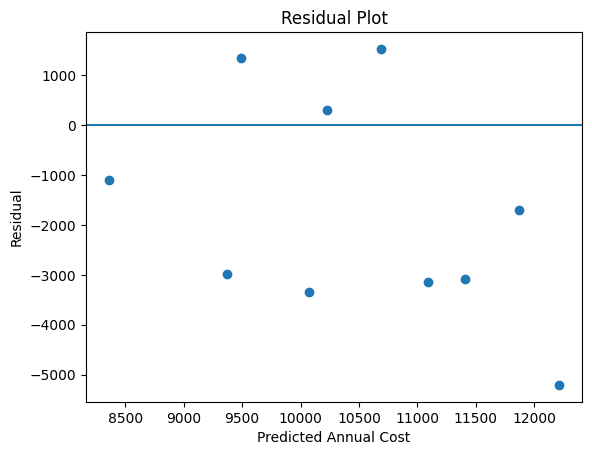

In [ ]:
residuals_2 = y_test - predictions_2

plt.scatter(predictions_2, residuals_2)

plt.axhline(y=0)

plt.xlabel("Predicted Annual Cost")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

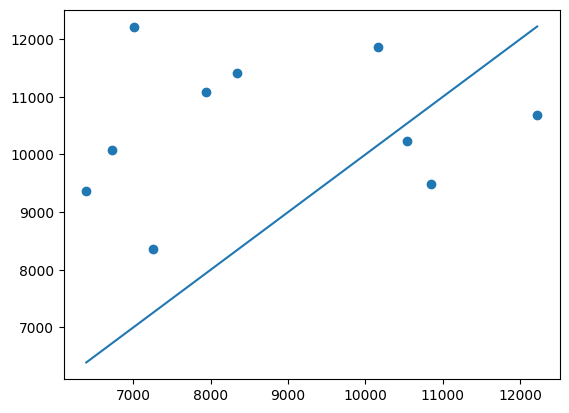

In [ ]:
plt.scatter(x = y_test, y = predictions_2)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.show()

In [ ]:
r2_rf = r2_score(y_test, predictions_2)
print(r2_rf)

-1.004640462672651


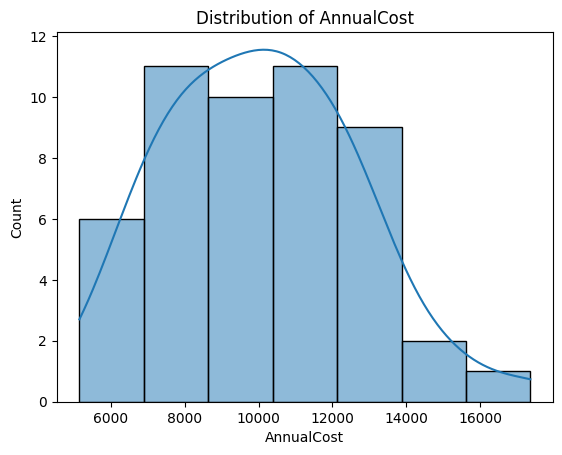

In [ ]:
sns.histplot(df["AnnualCost"], kde=True)
plt.title("Distribution of AnnualCost")
plt.show()

## CLASSIFICATION

### LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression

classification_model = LogisticRegression(max_iter = 2000)

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['SmokingStatus'] = encoder.fit_transform(df['SmokingStatus'])

X = df.drop(columns=["PatientID", "ChronicCondition"])
Y = df["ChronicCondition"]

print(X.head())

from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits = 5, shuffle = True, random_state = 42)

scores = cross_val_score(classification_model, X, Y, cv = kfold, scoring = 'accuracy')
print(scores.mean())

   Age   BMI  SmokingStatus  AnnualCost
0   58  37.0              0     6725.12
1   71  33.1              1    17359.16
2   48  28.2              1     7259.34
3   34  18.8              0    12287.21
4   62  38.8              0     8334.85
0.45999999999999996


### RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, min_samples_leaf = 3, random_state = 40)

df['ChronicCondition'] = encoder.fit_transform(df['ChronicCondition'])

print(X.head())

from sklearn.model_selection import StratifiedKFold, cross_val_score

kfold = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

scores = cross_val_score(rf, X, Y, cv = kfold, scoring = 'accuracy')
print(scores.mean())

   Age   BMI  SmokingStatus  AnnualCost
0   58  37.0              0     6725.12
1   71  33.1              1    17359.16
2   48  28.2              1     7259.34
3   34  18.8              0    12287.21
4   62  38.8              0     8334.85
0.41999999999999993
